In [18]:
# ============================================================
#  Ścieżki i standardowy wykres
# ============================================================

def geometry_folder_name(plot_type):
    """
    Zamienia aliasy plot_type na nazwę folderu w results/<folder>/...

    Przykłady:
        plot_type="truesnake"  -> results/truesnake/...
        plot_type="snake"      -> results/snake/...
        plot_type="semi-snake" -> results/snake/...
        plot_type="pila"       -> results/pila/...
        plot_type="snake_rows" -> results/snake_rows/...
    """

    pt = plot_type.lower()

    if pt in ["pila", "piła", "bottom", "bottomup", "bottom-up", "saw"]:
        return "pila"

    if pt in ["snake", "semisnake", "semi-snake", "semi_snake"]:
        return "snake"

    if pt in ["truesnake", "true_snake", "true-snake"]:
        return "truesnake"

    if pt in ["snake_rows", "rows", "horizontal", "row-snake"]:
        return "snake_rows"

    raise ValueError(
        "Nieznany plot_type. Dostępne foldery: "
        "'pila', 'snake', 'truesnake', 'snake_rows'."
    )


def make_current_path(
    Nx, Ny,
    yperiodic,
    Jx, Jy, Jz,
    r,
    theta, phi,
    mg_site,
    component,
    secondspin=False,
    fixed_pos=None,
    plot_type="truesnake",
):
    yp = yperiodic_string(yperiodic)
    geom_folder = geometry_folder_name(plot_type)

    if secondspin:
        filename = f"{component}_2spins_fixed{fixed_pos}"
    else:
        filename = component

    path = (
        f"results/{geom_folder}/"
        f"{Nx}x{Ny}_PBC={yp}_Jx={Jx}_Jy={Jy}_Jz={Jz}_r={r}"
        f"/Savrg_theta={theta}_phi={phi}_{mg_site}/{filename}.dat"
    )

    return path


def plot_current_lattice(
    plot_type="truesnake",
    path=None,
    show_labels="auto",
    cmap="bwr",
    vmin=-0.5,
    vmax=0.5,
    log_abs=False,
    eps=1e-12,
    cbar_label=None,
):
    """
    Rysuje wykres dla aktualnie ustawionych zmiennych:
    Nx, Ny, yperiodic, Jx, Jy, Jz, r, theta, phi,
    component, mg_site, secondspin, fixed_pos.

    Dane czyta z:
        results/<plot_type>/{Nx}x{Ny}_PBC=.../Savrg_theta=.../
    """

    yp_bool = as_bool(yperiodic)

    if path is None:
        path = make_current_path(
            Nx=Nx,
            Ny=Ny,
            yperiodic=yperiodic,
            Jx=Jx,
            Jy=Jy,
            Jz=Jz,
            r=r,
            theta=theta,
            phi=phi,
            mg_site=mg_site,
            component=component,
            secondspin=secondspin,
            fixed_pos=fixed_pos,
            plot_type=plot_type,
        )

    print("Reading from:")
    print(path)

    bonds, pos = get_lattice_geometry(
        Nx,
        Ny,
        plot_type=plot_type,
        yperiodic=yp_bool,
    )

    _, vals, mg_sites = load_component(path)

    safety = 0.8 if Nx > Ny else 0.85

    xmin, ymin = pos.min(axis=0)
    xmax, ymax = pos.max(axis=0)

    width = xmax - xmin
    height = ymax - ymin
    aspect = width / height

    base = 9

    if aspect > 1:
        fig_w = base
        fig_h = base / aspect
    else:
        fig_h = base
        fig_w = base * aspect

    plt.figure(figsize=(fig_w, fig_h), constrained_layout=True)

    plot_lattice_values(
        Nx,
        Ny,
        bonds,
        pos,
        vals,
        mg_sites=mg_sites,
        mg_site=mg_site,
        fixed_pos=fixed_pos,
        secondspin=secondspin,
        title=f"{component} on {Nx}x{Ny} honeycomb, {plot_type}",
        safety=safety,
        show_labels=show_labels,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        log_abs=log_abs,
        eps=eps,
        cbar_label=cbar_label,
    )

    plt.show()


# ============================================================
#  Suma Sx + Sy + Sz
# ============================================================

def load_spin_sum(
    Nx, Ny,
    yperiodic,
    Jx, Jy, Jz,
    r,
    theta, phi,
    mg_site,
    secondspin=False,
    fixed_pos=None,
    plot_type="truesnake",
):
    """
    Wczytuje Sx, Sy, Sz i zwraca sumę:
        Ssum_i = Sx_i + Sy_i + Sz_i

    Dane czyta z:
        results/<plot_type>/{Nx}x{Ny}_PBC=.../Savrg_theta=.../
    """

    components = ["Sx", "Sy", "Sz"]

    vals_sum = None
    sites_ref = None
    mg_sites_ref = None

    for comp in components:
        path = make_current_path(
            Nx=Nx,
            Ny=Ny,
            yperiodic=yperiodic,
            Jx=Jx,
            Jy=Jy,
            Jz=Jz,
            r=r,
            theta=theta,
            phi=phi,
            mg_site=mg_site,
            component=comp,
            secondspin=secondspin,
            fixed_pos=fixed_pos,
            plot_type=plot_type,
        )

        sites, vals, mg_sites = load_component(path)

        if vals_sum is None:
            vals_sum = vals.copy()
            sites_ref = sites
            mg_sites_ref = mg_sites
        else:
            if not np.array_equal(sites, sites_ref):
                raise ValueError(f"Niezgodne indeksy site w pliku {comp}.dat")

            if mg_sites != mg_sites_ref:
                raise ValueError(f"Niezgodne mg_sites w pliku {comp}.dat")

            vals_sum += vals

    return sites_ref, vals_sum, mg_sites_ref


def plot_current_spin_sum(
    plot_type="truesnake",
    show_labels="auto",
    cmap="bwr",
    vmin=-1.5,
    vmax=1.5,
    log_abs=False,
    eps=1e-12,
    cbar_label=None,
):
    """
    Rysuje sumę:
        Sx + Sy + Sz
    """

    yp_bool = as_bool(yperiodic)

    bonds, pos = get_lattice_geometry(
        Nx,
        Ny,
        plot_type=plot_type,
        yperiodic=yp_bool,
    )

    _, vals_sum, mg_sites = load_spin_sum(
        Nx=Nx,
        Ny=Ny,
        yperiodic=yperiodic,
        Jx=Jx,
        Jy=Jy,
        Jz=Jz,
        r=r,
        theta=theta,
        phi=phi,
        mg_site=mg_site,
        secondspin=secondspin,
        fixed_pos=fixed_pos,
        plot_type=plot_type,
    )

    safety = 0.8 if Nx > Ny else 0.85

    xmin, ymin = pos.min(axis=0)
    xmax, ymax = pos.max(axis=0)

    width = xmax - xmin
    height = ymax - ymin
    aspect = width / height

    base = 9

    if aspect > 1:
        fig_w = base
        fig_h = base / aspect
    else:
        fig_h = base
        fig_w = base * aspect

    plt.figure(figsize=(fig_w, fig_h), constrained_layout=True)

    plot_lattice_values(
        Nx,
        Ny,
        bonds,
        pos,
        vals_sum,
        mg_sites=mg_sites,
        mg_site=mg_site,
        fixed_pos=fixed_pos,
        secondspin=secondspin,
        title=f"Sx + Sy + Sz on {Nx}x{Ny} honeycomb, {plot_type}",
        safety=safety,
        show_labels=show_labels,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        log_abs=log_abs,
        eps=eps,
        cbar_label=cbar_label,
    )

    plt.show()


# ============================================================
#  Wszystkie składowe Sx, Sy, Sz w jednym kółku
# ============================================================

def load_spin_components(
    Nx, Ny,
    yperiodic,
    Jx, Jy, Jz,
    r,
    theta, phi,
    mg_site,
    secondspin=False,
    fixed_pos=None,
    plot_type="truesnake",
):
    """
    Wczytuje Sx, Sy, Sz dla aktualnych parametrów.

    Zwraca:
        sites, vals_x, vals_y, vals_z, mg_sites

    Dane czyta z:
        results/<plot_type>/{Nx}x{Ny}_PBC=.../Savrg_theta=.../
    """

    components = ["Sx", "Sy", "Sz"]
    data = {}

    sites_ref = None
    mg_sites_ref = None

    for comp in components:
        path = make_current_path(
            Nx=Nx,
            Ny=Ny,
            yperiodic=yperiodic,
            Jx=Jx,
            Jy=Jy,
            Jz=Jz,
            r=r,
            theta=theta,
            phi=phi,
            mg_site=mg_site,
            component=comp,
            secondspin=secondspin,
            fixed_pos=fixed_pos,
            plot_type=plot_type,
        )

        print(f"Reading {comp} from:")
        print(path)

        sites, vals, mg_sites = load_component(path)

        if sites_ref is None:
            sites_ref = sites
            mg_sites_ref = mg_sites
        else:
            if not np.array_equal(sites, sites_ref):
                raise ValueError(f"Niezgodne indeksy site w pliku {comp}.dat")

            if mg_sites != mg_sites_ref:
                raise ValueError(f"Niezgodne mg_sites w pliku {comp}.dat")

        data[comp] = vals

    return sites_ref, data["Sx"], data["Sy"], data["Sz"], mg_sites_ref


def plot_current_all_spin_components(
    plot_type="truesnake",
    show_labels="auto",
    cmap="bwr",
    vmin=-0.5,
    vmax=0.5,
    radius_scale=0.33,
    log_abs=False,
    eps=1e-12,
    cbar_label=None,
):
    """
    Rysuje Sx, Sy, Sz jednocześnie.
    Każdy site jest kółkiem podzielonym na trzy sektory.

    Dane czyta z:
        results/<plot_type>/{Nx}x{Ny}_PBC=.../Savrg_theta=.../

    Przykłady:
        plot_current_all_spin_components(plot_type="truesnake")
        plot_current_all_spin_components(plot_type="snake")
        plot_current_all_spin_components(plot_type="pila")
        plot_current_all_spin_components(plot_type="snake_rows")
    """

    yp_bool = as_bool(yperiodic)

    bonds, pos = get_lattice_geometry(
        Nx,
        Ny,
        plot_type=plot_type,
        yperiodic=yp_bool,
    )

    _, vals_x, vals_y, vals_z, mg_sites = load_spin_components(
        Nx=Nx,
        Ny=Ny,
        yperiodic=yperiodic,
        Jx=Jx,
        Jy=Jy,
        Jz=Jz,
        r=r,
        theta=theta,
        phi=phi,
        mg_site=mg_site,
        secondspin=secondspin,
        fixed_pos=fixed_pos,
        plot_type=plot_type,
    )

    xmin, ymin = pos.min(axis=0)
    xmax, ymax = pos.max(axis=0)

    width = xmax - xmin
    height = ymax - ymin
    aspect = width / height

    base = 9

    if aspect > 1:
        fig_w = base
        fig_h = base / aspect
    else:
        fig_h = base
        fig_w = base * aspect

    plt.figure(figsize=(fig_w, fig_h), constrained_layout=True)

    plot_lattice_all_spin_components(
        Nx,
        Ny,
        bonds,
        pos,
        vals_x,
        vals_y,
        vals_z,
        mg_sites=mg_sites,
        mg_site=mg_site,
        fixed_pos=fixed_pos,
        secondspin=secondspin,
        title=f"Sx / Sy / Sz on {Nx}x{Ny} honeycomb, {plot_type}",
        show_labels=show_labels,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        radius_scale=radius_scale,
        log_abs=log_abs,
        eps=eps,
        cbar_label=cbar_label,
    )

    plt.show()


# ============================================================
#  DMRG log
# ============================================================

import os
import re


def make_dmrg_base_folder(
    plot_type="truesnake",
    Nx_val=None,
    Ny_val=None,
    yperiodic_val=None,
    Jx_val=None,
    Jy_val=None,
    Jz_val=None,
    r_val=None,
):
    if Nx_val is None:
        Nx_val = Nx
    if Ny_val is None:
        Ny_val = Ny
    if yperiodic_val is None:
        yperiodic_val = yperiodic
    if Jx_val is None:
        Jx_val = Jx
    if Jy_val is None:
        Jy_val = Jy
    if Jz_val is None:
        Jz_val = Jz
    if r_val is None:
        r_val = r

    yp = yperiodic_string(yperiodic_val)

    # tutaj NIE MA mapowania typu saw -> pila
    # dokładnie taki folder, jaki podasz w plot_type
    geom_folder = str(plot_type)

    folder = (
        f"{Nx_val}x{Ny_val}_PBC={yp}_"
        f"Jx={Jx_val}_Jy={Jy_val}_Jz={Jz_val}_r={r_val}"
    )

    return f"results/{geom_folder}/{folder}"


def make_dmrg_log_file(
    plot_type="truesnake",
    theta_val=None,
    phi_val=None,
    mg_site_val=None,
    Nx_val=None,
    Ny_val=None,
    yperiodic_val=None,
    Jx_val=None,
    Jy_val=None,
    Jz_val=None,
    r_val=None,
):
    if theta_val is None:
        theta_val = theta
    if phi_val is None:
        phi_val = phi
    if mg_site_val is None:
        mg_site_val = mg_site

    base_folder = make_dmrg_base_folder(
        plot_type=plot_type,
        Nx_val=Nx_val,
        Ny_val=Ny_val,
        yperiodic_val=yperiodic_val,
        Jx_val=Jx_val,
        Jy_val=Jy_val,
        Jz_val=Jz_val,
        r_val=r_val,
    )

    subfolder = f"Savrg_theta={theta_val}_phi={phi_val}_{mg_site_val}"

    return f"{base_folder}/{subfolder}/dmrg_log.dat"


def load_dmrg_log(
    plot_type="truesnake",
    theta_val=None,
    phi_val=None,
    mg_site_val=None,
    Nx_val=None,
    Ny_val=None,
    yperiodic_val=None,
    Jx_val=None,
    Jy_val=None,
    Jz_val=None,
    r_val=None,
):
    """
    Wczytuje dmrg_log.dat z:

        results/<plot_type>/{Nx}x{Ny}_PBC=.../Savrg_theta=.../dmrg_log.dat

    gdzie <plot_type> jest użyte DOSŁOWNIE jako nazwa folderu.
    """

    file_path = make_dmrg_log_file(
        plot_type=plot_type,
        theta_val=theta_val,
        phi_val=phi_val,
        mg_site_val=mg_site_val,
        Nx_val=Nx_val,
        Ny_val=Ny_val,
        yperiodic_val=yperiodic_val,
        Jx_val=Jx_val,
        Jy_val=Jy_val,
        Jz_val=Jz_val,
        r_val=r_val,
    )

    if not os.path.isfile(file_path):
        raise FileNotFoundError(f"Nie znaleziono pliku:\n{file_path}")

    data = pd.read_csv(
        file_path,
        sep=r"\s+",
        comment="#",
        names=["sweep", "energy", "spin", "maxdim", "dmrg_maxerr"],
    )

    return data, file_path


def find_dmrg_logs_for_all_angles(
    plot_type="truesnake",
    mg_site_val=None,
    Nx_val=None,
    Ny_val=None,
    yperiodic_val=None,
    Jx_val=None,
    Jy_val=None,
    Jz_val=None,
    r_val=None,
):
    """
    Szuka wszystkich dmrg_log.dat dla danej numeracji/folderu.

    Szuka w:

        results/<plot_type>/{Nx}x{Ny}_PBC=.../

    folderów typu:

        Savrg_theta=..._phi=..._<mg_site>
    """

    if mg_site_val is None:
        mg_site_val = mg_site

    base_folder = make_dmrg_base_folder(
        plot_type=plot_type,
        Nx_val=Nx_val,
        Ny_val=Ny_val,
        yperiodic_val=yperiodic_val,
        Jx_val=Jx_val,
        Jy_val=Jy_val,
        Jz_val=Jz_val,
        r_val=r_val,
    )

    if not os.path.isdir(base_folder):
        print(f"Nie ma folderu: {base_folder}")
        return []

    pattern_end = f"_{mg_site_val}"

    out = []

    for name in sorted(os.listdir(base_folder)):
        full_folder = f"{base_folder}/{name}"

        if not os.path.isdir(full_folder):
            continue

        if not name.startswith("Savrg_theta="):
            continue

        if not name.endswith(pattern_end):
            continue

        log_file = f"{full_folder}/dmrg_log.dat"

        if not os.path.isfile(log_file):
            continue

        m = re.match(r"Savrg_theta=(.*)_phi=(.*)_(\d+)$", name)

        if m is None:
            theta_found = "?"
            phi_found = "?"
            mg_found = mg_site_val
        else:
            theta_found = m.group(1)
            phi_found = m.group(2)
            mg_found = int(m.group(3))

        out.append(
            {
                "file": log_file,
                "theta": theta_found,
                "phi": phi_found,
                "mg_site": mg_found,
                "plot_type": plot_type,
            }
        )

    return out


def plot_dmrg_quantity(
    plot_quantity="energy",
    logy=False,
    marker="o",
    plot_type="truesnake",
    angles="current",
    theta_phi_list=None,
    mg_site_val=None,
):
    """
    Rysuje wybraną wielkość z dmrg_log.dat.

    Przykłady:

        plot_dmrg_quantity("energy", plot_type="saw")

        plot_dmrg_quantity("energy", plot_type=["truesnake", "saw"])

        plot_dmrg_quantity("energy", plot_type="saw", angles="all")

        plot_dmrg_quantity("energy", plot_type=["truesnake", "saw"], angles="all")

        plot_dmrg_quantity(
            "energy",
            plot_type="saw",
            theta_phi_list=[
                (0.304*np.pi, np.pi/4),
                (0.5*np.pi, np.pi/4),
            ]
        )
    """

    allowed = ["energy", "spin", "maxdim", "dmrg_maxerr"]

    if plot_quantity not in allowed:
        raise ValueError(f"plot_quantity musi być jednym z: {allowed}")

    if isinstance(plot_type, str):
        plot_types = [plot_type]
    else:
        plot_types = list(plot_type)

    if mg_site_val is None:
        mg_site_val = mg_site

    plt.figure(figsize=(8, 5))

    all_data = []

    for pt in plot_types:

        # ====================================================
        # aktualne theta, phi
        # ====================================================
        if angles == "current" and theta_phi_list is None:
            data, file_path = load_dmrg_log(
                plot_type=pt,
                theta_val=theta,
                phi_val=phi,
                mg_site_val=mg_site_val,
            )

            label = f"{pt}, θ={theta:.4g}, φ={phi:.4g}"

            plt.plot(
                data["sweep"],
                data[plot_quantity],
                marker=marker,
                label=label,
            )

            all_data.append((label, data, file_path))

        # ====================================================
        # ręcznie podana lista kątów
        # ====================================================
        elif theta_phi_list is not None:
            for theta_val, phi_val in theta_phi_list:
                data, file_path = load_dmrg_log(
                    plot_type=pt,
                    theta_val=theta_val,
                    phi_val=phi_val,
                    mg_site_val=mg_site_val,
                )

                label = f"{pt}, θ={theta_val:.4g}, φ={phi_val:.4g}"

                plt.plot(
                    data["sweep"],
                    data[plot_quantity],
                    marker=marker,
                    label=label,
                )

                all_data.append((label, data, file_path))

        # ====================================================
        # wszystkie znalezione kąty
        # ====================================================
        elif angles == "all":
            logs = find_dmrg_logs_for_all_angles(
                plot_type=pt,
                mg_site_val=mg_site_val,
            )

            if len(logs) == 0:
                print(f"Nie znaleziono logów dla plot_type = {pt}")
                continue

            for item in logs:
                file_path = item["file"]

                data = pd.read_csv(
                    file_path,
                    sep=r"\s+",
                    comment="#",
                    names=["sweep", "energy", "spin", "maxdim", "dmrg_maxerr"],
                )

                label = (
                    f"{pt}, "
                    f"θ={item['theta']}, "
                    f"φ={item['phi']}"
                )

                plt.plot(
                    data["sweep"],
                    data[plot_quantity],
                    marker=marker,
                    label=label,
                )

                all_data.append((label, data, file_path))

        else:
            raise ValueError(
                "Nieznany tryb angles. Użyj angles='current', angles='all' "
                "albo podaj theta_phi_list=[(theta1, phi1), ...]."
            )

    plt.xlabel("Sweep")
    plt.ylabel(plot_quantity)

    if isinstance(plot_type, str):
        title_pt = plot_type
    else:
        title_pt = ", ".join(plot_types)

    plt.title(f"{plot_quantity}(sweep), {title_pt}")

    if logy:
        plt.yscale("log")

    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    return all_data

In [16]:
def load_corr_component(path):
    """
    Wczytuje plik typu Sx_corr.dat, Sy_corr.dat, Sz_corr.dat.

    Format:
    # i    1    2    3 ...
    1      C11  C12  C13 ...
    2      C21  C22  C23 ...
    ...

    Zwraca:
        sites : array shape (Nsites,)
        C     : array shape (Nsites, Nsites)
    """
    data = np.loadtxt(path)
    sites = data[:, 0].astype(int)
    C = data[:, 1:]
    return sites, C

def make_current_corr_path(
    Nx, Ny,
    yperiodic,
    Jx, Jy, Jz,
    r,
    theta, phi,
    mg_site,
    component,
):
    yp = yperiodic_string(yperiodic)

    path = (
        f"results/{Nx}x{Ny}_PBC={yp}_Jx={Jx}_Jy={Jy}_Jz={Jz}_r={r}"
        f"/Savrg_theta={theta}_phi={phi}_{mg_site}/{component}_corr.dat"
    )

    return path

def load_spin_correlations(
    Nx, Ny,
    yperiodic,
    Jx, Jy, Jz,
    r,
    theta, phi,
    mg_site,
):
    """
    Wczytuje Sx_corr.dat, Sy_corr.dat, Sz_corr.dat.

    Zwraca:
        sites, Cx, Cy, Cz
    """

    corr_data = {}
    sites_ref = None

    for comp in ["Sx", "Sy", "Sz"]:
        path = make_current_corr_path(
            Nx=Nx,
            Ny=Ny,
            yperiodic=yperiodic,
            Jx=Jx,
            Jy=Jy,
            Jz=Jz,
            r=r,
            theta=theta,
            phi=phi,
            mg_site=mg_site,
            component=comp,
        )

        sites, C = load_corr_component(path)

        if sites_ref is None:
            sites_ref = sites
        else:
            if not np.array_equal(sites, sites_ref):
                raise ValueError(f"Niezgodne indeksy site w pliku {comp}_corr.dat")

        corr_data[comp] = C

    return sites_ref, corr_data["Sx"], corr_data["Sy"], corr_data["Sz"]

def get_correlations_from_site(C, sites, ref_site):
    """
    Z macierzy korelacji C[i,j] wyciąga wektor:
        C(ref_site, j)

    Zwraca 1D array długości Nsites.
    """
    idx = np.where(sites == ref_site)[0]

    if len(idx) == 0:
        raise ValueError(f"Site {ref_site} nie został znaleziony w macierzy korelacji.")

    idx = idx[0]
    return C[idx, :]

def plot_current_all_spin_correlations(
    ref_site=None,
    plot_type="truesnake",
    show_labels="auto",
    cmap="bwr",
    vmin=-0.25,
    vmax=0.25,
    radius_scale=0.33,
    log_abs=False,
    eps=1e-12,
    cbar_label=None
):
    """
    Rysuje dla wybranego site'u referencyjnego korelacje:
        <Sx(ref_site) Sx(j)>
        <Sy(ref_site) Sy(j)>
        <Sz(ref_site) Sz(j)>

    Każdy site jest kółkiem podzielonym na 3 sektory,
    dokładnie jak w plot_current_all_spin_components().

    Jeśli ref_site=None, używa mg_site.
    """

    if ref_site is None:
        ref_site = mg_site

    yp_bool = as_bool(yperiodic)

    bonds, pos = get_lattice_geometry(
        Nx,
        Ny,
        plot_type=plot_type,
        yperiodic=yp_bool,
    )

    sites, Cx, Cy, Cz = load_spin_correlations(
        Nx=Nx,
        Ny=Ny,
        yperiodic=yperiodic,
        Jx=Jx,
        Jy=Jy,
        Jz=Jz,
        r=r,
        theta=theta,
        phi=phi,
        mg_site=mg_site,
    )

    vals_x = get_correlations_from_site(Cx, sites, ref_site)
    vals_y = get_correlations_from_site(Cy, sites, ref_site)
    vals_z = get_correlations_from_site(Cz, sites, ref_site)

    xmin, ymin = pos.min(axis=0)
    xmax, ymax = pos.max(axis=0)

    width = xmax - xmin
    height = ymax - ymin
    aspect = width / height

    base = 9

    if aspect > 1:
        fig_w = base
        fig_h = base / aspect
    else:
        fig_h = base
        fig_w = base * aspect

    plt.figure(figsize=(fig_w, fig_h), constrained_layout=True)

    if cbar_label is None:
        if log_abs:
            cbar_label = r"$\log_{10}(|\langle S_\alpha(i) S_\alpha(j)\rangle|)$"
        else:
            cbar_label = rf"$\langle S_\alpha({ref_site})\,S_\alpha(j)\rangle$"

    plot_lattice_all_spin_components(
        Nx,
        Ny,
        bonds,
        pos,
        vals_x,
        vals_y,
        vals_z,
        mg_sites=None,
        mg_site=ref_site,
        fixed_pos=fixed_pos,
        secondspin=secondspin,
        title=f"Spin correlations from site {ref_site} on {Nx}x{Ny} honeycomb, {plot_type}",
        show_labels=show_labels,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        radius_scale=radius_scale,
        log_abs=log_abs,
        eps=eps,
        cbar_label=cbar_label
    )

    plt.show()

In [67]:
"""
    Rysuje wykres dla aktualnie ustawionych zmiennych:
    Nx, Ny, yperiodic, Jx, Jy, Jz, r, theta, phi,
    component, mg_site, secondspin, fixed_pos.

    plot_type:
        "pila"
        "snake"
        "truesnake"
        "snake_rows"
    """

Nx = 5
Ny = 4

secondspin = False
fixed_pos = 2

component = "Sx"
mg_site = 20

yperiodic = "false"

Jx = -1.0
Jy = -1.0
Jz = -1.0
r = 1.0

theta = 0.0
phi = 0.0

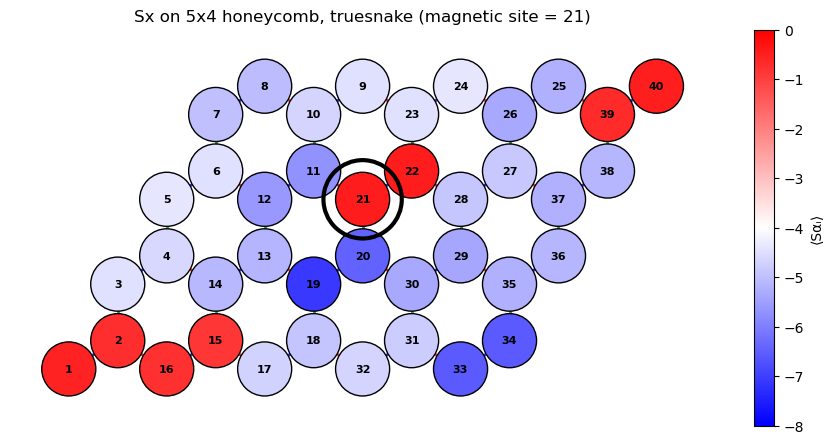

In [7]:
plot_current_lattice(
    plot_type="truesnake",
    log_abs=True,
    vmin=-8,
    vmax=0,
)

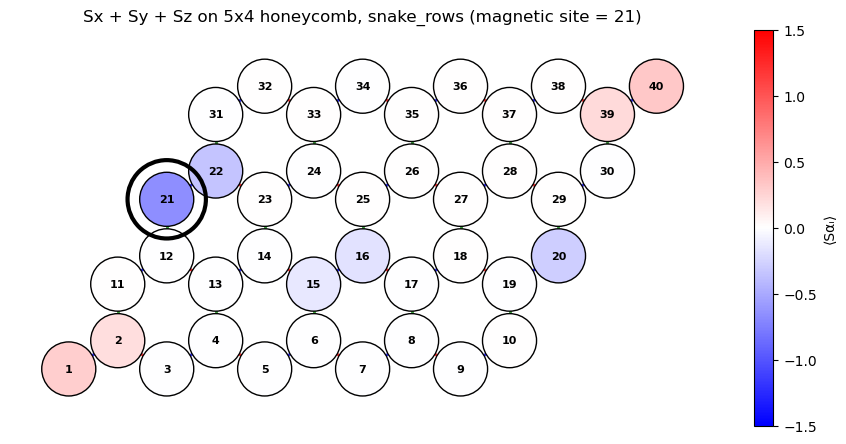

In [8]:
plot_current_spin_sum(plot_type="snake_rows")

Reading Sx from:
results/pila/5x4_PBC=false_Jx=-1.0_Jy=-1.0_Jz=-1.0_r=1.0/Savrg_theta=0.0_phi=0.0_20/Sx.dat
Reading Sy from:
results/pila/5x4_PBC=false_Jx=-1.0_Jy=-1.0_Jz=-1.0_r=1.0/Savrg_theta=0.0_phi=0.0_20/Sy.dat
Reading Sz from:
results/pila/5x4_PBC=false_Jx=-1.0_Jy=-1.0_Jz=-1.0_r=1.0/Savrg_theta=0.0_phi=0.0_20/Sz.dat


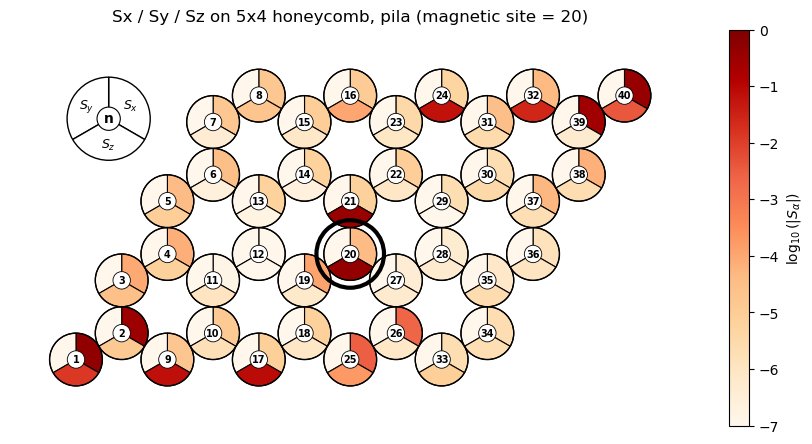

In [72]:
tab20 = plt.get_cmap("Paired")
colors8 = tab20(np.arange(0, 8))#[::-1]
cmap8 = ListedColormap(colors8)

plot_current_all_spin_components(
    plot_type="pila",
    radius_scale=0.5,
    log_abs=True,
    vmin=-7.0,
    vmax=0.0,
    eps=1e-12,
    cmap="OrRd",
)

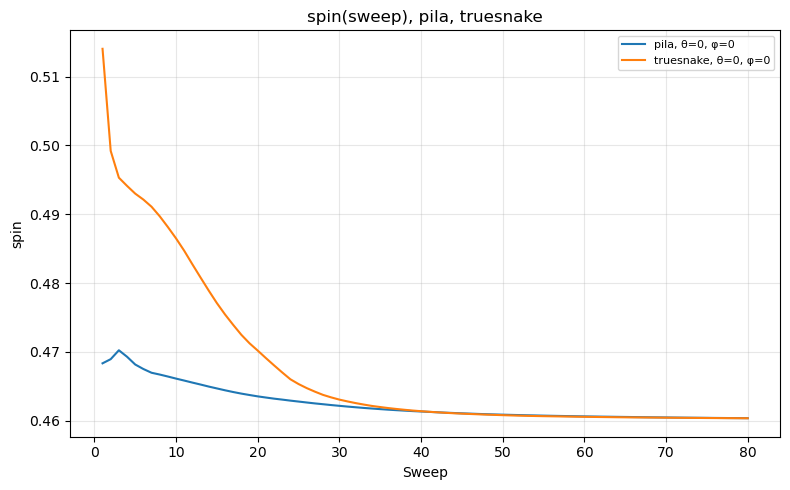

[('pila, θ=0, φ=0',
      sweep    energy      spin  maxdim   dmrg_maxerr
  0       1 -7.294384  0.468340      50  4.161446e-05
  1       2 -7.344138  0.468946     100  2.001379e-05
  2       3 -7.374490  0.470236     150  1.528129e-05
  3       4 -7.391961  0.469295     200  6.231298e-06
  4       5 -7.402286  0.468169     300  5.493417e-07
  ..    ...       ...       ...     ...           ...
  75     76 -7.412785  0.460403    1937  1.267277e-07
  76     77 -7.412772  0.460394    1972  1.217416e-07
  77     78 -7.412778  0.460384    1988  1.822221e-07
  78     79 -7.412801  0.460376    1921  7.246033e-08
  79     80 -7.412796  0.460366    1994  9.852771e-08
  
  [80 rows x 5 columns],
  'results/pila/5x4_PBC=false_Jx=-1.0_Jy=-1.0_Jz=-1.0_r=1.0/Savrg_theta=0.0_phi=0.0_20/dmrg_log.dat'),
 ('truesnake, θ=0, φ=0',
      sweep    energy      spin  maxdim   dmrg_maxerr
  0       1 -7.271436  0.514043      50  2.475528e-04
  1       2 -7.335168  0.499207     100  7.433513e-05
  2       3 -7

In [71]:
#["energy", "spin", "maxdim", "dmrg_maxerr"]
plot_dmrg_quantity(
    plot_quantity="spin",
    plot_type=["pila", "truesnake"],
    #angles="all",
    marker=None,
    mg_site_val=20,
)

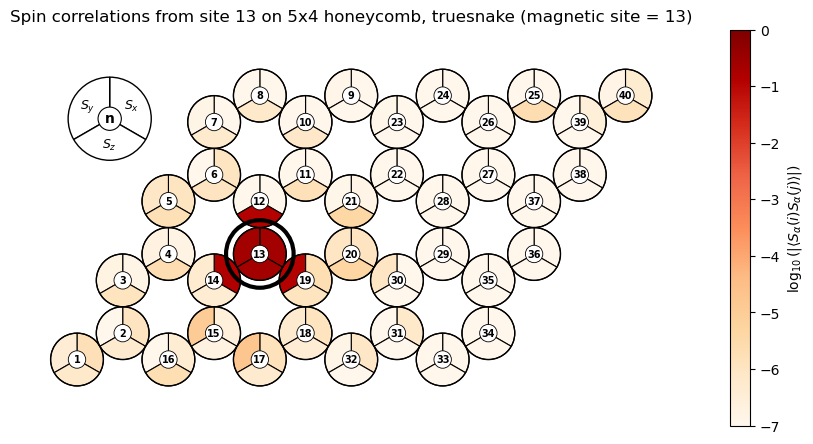

In [48]:
plot_current_all_spin_correlations(ref_site=13, vmin=-7, vmax=0, log_abs=True, 
                                   radius_scale=0.5, cmap="OrRd")